# Comparison of SSL pretraining variants on downstream survival modelling
This notebook compares the performance of different SSL pretraining variants on downstream survival modelling. Three pretrained encoders are considered, namely the simple version (SimCLR), the time-frequency consistency (TFC) and survival guided TFC encoder, and their performance is evaluated against respective random initialization. The highest perfoming model on the validation set will be selected as the representing SSL variant for subesequent fine tuning phase of the proposed approach. This experiment is performed on the same truncated sequences used throughout this study.

In [1]:
# fix randomness
import torch
import numpy as np
import random

seed = 0

torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [ ]:
# Set project paths and enable imports from src, models and data directories
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
DATA_DIR = PROJECT_ROOT / "data" / "processed" / "sequences"
MODELS_DIR = PROJECT_ROOT / "models"

for path in [SRC_DIR, DATA_DIR, MODELS_DIR]:
    if str(path) not in sys.path:
        sys.path.append(str(path))

print(f"Notebook location: {Path.cwd()}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Source directory: {SRC_DIR}")
print(f"Models directory: {MODELS_DIR}")
print(f"Sequences directory: {DATA_DIR}")

Source files: ['__init__.py', 'utils.py', 'quality_checks.py', 'feature_engineering.py', 'data_loading.py', 'preprocessing.py', 'sequence_preprocessing.py', 'sequence_builder.py', '__pycache__', 'survival_dataset.py', 'ssl_model.py', 'tfc_preprocessing.py', 'surv_fin_tun_dataset.py', 'tfc_stochastic_preprocessing.py', 'ssl_dataset.py', 'surv_fin_tun_dataset_pseudo.py', 'ssl_tfc_model.py']
Data files: ['val_sequences.pkl', 'train_sequences.pkl', 'test_sequences.pkl', 'sequence_normalizer.pkl', 'truncated_train_sequences.pkl', 'truncated_val_sequences.pkl', 'truncated_sequence_normalizer.pkl', 'truncated_test_sequences.pkl', 'train_sequences_ssl.pkl', 'val_sequences_ssl.pkl', 'test_sequences_ssl.pkl', 'time_gap_normalizer.pkl', 'truncated_train_sequences_enc.pkl', 'truncated_val_sequences_enc.pkl', 'truncated_sequence_encoder.pkl', 'truncated_test_sequences_enc.pkl']


In [4]:
# check runtime GPU
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch version: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA A100-SXM4-40GB


In [ ]:
# load the truncated sequences

import pickle

with open(DATA_DIR / "train_sequences_truncated.pkl", "rb") as f:
    truncated_train_seq = pickle.load(f)

with open(DATA_DIR / "val_sequences_truncated.pkl", "rb") as f:
    truncated_val_seq = pickle.load(f)

print(len(truncated_train_seq), len(truncated_val_seq))

16485 3532
dict_keys(['means', 'stds'])


In [6]:
# inspect one sample
first_vehicle = next(iter(truncated_train_seq))
sample_seq = truncated_train_seq[first_vehicle]

print("Vehicle id:", first_vehicle)
print("Keys:", sample_seq.keys())
print("Numerical shape:", sample_seq["numerical_sequence"].shape)
print("Histogram shape:", sample_seq["histogram_sequence"].shape)
print("Sequence length:", sample_seq["sequence_length"])
print("Static features:", sample_seq["static_features_encoded"].shape)
print("Duration:", sample_seq["duration"])
print("Event:", sample_seq["event"])
print("Readout time:", sample_seq["readout_time"])
print("Original duration:", sample_seq["original_duration"])

Vehicle id: 18034
Keys: dict_keys(['vehicle_id', 'time_steps', 'time_gaps', 'numerical_sequence', 'histogram_sequence', 'sequence_length', 'static_features', 'duration', 'event', 'readout_time', 'original_duration', 'static_features_encoded'])
Numerical shape: (11, 8)
Histogram shape: (11, 97)
Sequence length: 11
Static features: (89,)
Duration: 214.2
Event: 1
Readout time: 65.2
Original duration: 279.4


In [ ]:
from surv_fin_tun_dataset import SurvivalSequenceDataset, survival_collate_fn
train_surv_dataset = SurvivalSequenceDataset(
    sequence_dict=truncated_train_seq,
    use_static_features=True,
)

val_surv_dataset = SurvivalSequenceDataset(
    sequence_dict=truncated_val_seq,
    use_static_features=True,
)

print(len(train_surv_dataset), len(val_surv_dataset))#, len(test_surv_dataset))

16485 3532


In [10]:
sample = train_surv_dataset[0]

print("Sample keys:", sample.keys())
print("Vehicle id:", sample["vehicle_id"])
print("Sequence length:", sample["sequence_length"])
print("Numerical shape:", sample["numerical"].shape)
print("Histogram shape:", sample["histogram"].shape)
print("Duration:", sample["duration"].item())
print("Event:", sample["event"].item())

if "readout_time" in sample:
    print("Readout time:", sample["readout_time"].item())

if "original_duration" in sample:
    print("Original duration:", sample["original_duration"].item())

Sample keys: dict_keys(['vehicle_id', 'sequence_length', 'time_steps', 'time_gaps', 'numerical', 'histogram', 'duration', 'event', 'readout_time', 'original_duration', 'static_features'])
Vehicle id: 0
Sequence length: 130
Numerical shape: torch.Size([130, 8])
Histogram shape: torch.Size([130, 97])
Duration: 118.0
Event: 0.0
Readout time: 392.0
Original duration: 510.0


In [ ]:
from torch.utils.data import DataLoader

train_surv_loader = DataLoader(
    train_surv_dataset,
    batch_size=128,
    shuffle=True,
    collate_fn=survival_collate_fn,
    num_workers=0,
)

val_surv_loader = DataLoader(
    val_surv_dataset,
    batch_size=256,
    shuffle=False,
    collate_fn=survival_collate_fn,
    num_workers=0,
)

## Loading the saved pretrained encoders
Three paths, each for the respective encoder

In [ ]:
# paths where pretrained ssl models are saved
save_path_tfc = MODELS_DIR / "tfc_pretrained_model_B3.pt"

save_path_surv_guid_tfc = MODELS_DIR / "survival_guided_tfc_results.pt"

save_path_simclr = MODELS_DIR / "ssl_pretrained_simclr.pt"

In [13]:
# Import model modules
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
from ssl_tfc_model import TFCSequenceModel, TFCSurvivalFineTuningModel
from ssl_model import SSLSequenceModel, SurvivalFineTuningModel

In [14]:
# TFC pretrained model
def build_tfc_pretrained_frozen_model():
    checkpoint = torch.load(save_path_tfc, map_location=device)

    encoder = TFCSequenceModel(
        time_input_dim=checkpoint["time_input_dim"],
        freq_input_dim=checkpoint["freq_input_dim"],
        time_hidden_dim=checkpoint["time_hidden_dim"],
        freq_hidden_dim=checkpoint["freq_hidden_dim"],
        projection_dim=checkpoint["projection_dim"],
    )

    encoder.load_state_dict(checkpoint["model_state_dict"])

    model = TFCSurvivalFineTuningModel(
        pretrained_tfc_model=encoder,
        survival_hidden_dim=64,
        freeze_encoder=True,
    )

    return model.to(device)

In [15]:
# define the tfc model
tfc_ssl_model = build_tfc_pretrained_frozen_model()

In [16]:
# Survival guided TFC pretrained model

def build_survival_guided_tfc_pretrained_frozen_model():
    checkpoint = torch.load(save_path_surv_guid_tfc, map_location=device, weights_only=False)

    encoder = TFCSequenceModel(
        time_input_dim=checkpoint["config"]["time_input_dim"],
        freq_input_dim=checkpoint["config"]["freq_input_dim"],
        time_hidden_dim=checkpoint["config"]["time_hidden_dim"],
        freq_hidden_dim=checkpoint["config"]["freq_hidden_dim"],
        projection_dim=checkpoint["config"]["projection_dim"],
    )
    encoder.load_state_dict(
        checkpoint["best_tfc_state_dict"]
    )

    model = TFCSurvivalFineTuningModel(
        pretrained_tfc_model= encoder,
        survival_hidden_dim=64,
        freeze_encoder=True,
    )
    return model.to(device)

In [17]:
# define the survival guided model
survival_guided_tfc_model = build_survival_guided_tfc_pretrained_frozen_model()

In [18]:
# SimCLR pretrained model
def build_simclr_pretrained_frozen_model():
    checkpoint = torch.load(save_path_simclr, map_location=device)

    encoder = SSLSequenceModel(
        numerical_dim=checkpoint["numerical_dim"],
        histogram_dim=checkpoint["histogram_dim"],
        numerical_hidden_dim=checkpoint["numerical_hidden_dim"],
        histogram_hidden_dim=checkpoint["histogram_hidden_dim"],
        projection_dim=checkpoint["projection_dim"],
    )

    encoder.load_state_dict(checkpoint["model_state_dict"])

    model = SurvivalFineTuningModel(
        pretrained_ssl_model=encoder,
        survival_hidden_dim=64,
        freeze_encoder=True,
    )

    return model.to(device)

In [19]:
# define simclr model
simclr_ssl_model = build_simclr_pretrained_frozen_model()

In [20]:
# Random TFC (weights randomly initialized)
def build_random_tfc_frozen_model():
    checkpoint = torch.load(save_path_tfc, map_location=device)

    encoder = TFCSequenceModel(
        time_input_dim=checkpoint["time_input_dim"],
        freq_input_dim=checkpoint["freq_input_dim"],
        time_hidden_dim=checkpoint["time_hidden_dim"],
        freq_hidden_dim=checkpoint["freq_hidden_dim"],
        projection_dim=checkpoint["projection_dim"],
    )

    # Important: no encoder.load_state_dict(...)
    # This keeps the encoder randomly initialized.

    model = TFCSurvivalFineTuningModel(
        pretrained_tfc_model=encoder,
        survival_hidden_dim=64,
        freeze_encoder=True,
    )

    return model.to(device)

In [21]:
# define random tfc model
random_tfc_model = build_random_tfc_frozen_model()

In [22]:
# Random SIMCLR
def build_random_simclr_frozen_model():
    checkpoint = torch.load(save_path_simclr, map_location=device)

    encoder = SSLSequenceModel(
        numerical_dim=checkpoint["numerical_dim"],
        histogram_dim=checkpoint["histogram_dim"],
        numerical_hidden_dim=checkpoint["numerical_hidden_dim"],
        histogram_hidden_dim=checkpoint["histogram_hidden_dim"],
        projection_dim=checkpoint["projection_dim"],
    )

    # Important: no encoder.load_state_dict(...)
    # This keeps the encoder randomly initialized.

    model = SurvivalFineTuningModel(
        pretrained_ssl_model=encoder,
        survival_hidden_dim=64,
        freeze_encoder=True,
    )

    return model.to(device)

In [23]:
# define random simclr model
random_simclr_model = build_random_simclr_frozen_model()

In [24]:
# define the negative Cox partial log likelihood as the loss function

def cox_partial_log_likelihood(
    risk_scores: torch.Tensor,
    durations: torch.Tensor,
    events: torch.Tensor,
    eps: float = 1e-8,
) -> torch.Tensor:
    """
    Negative Cox partial log-likelihood.

    Parameters
    ----------
    risk_scores : torch.Tensor
        Predicted scalar risk scores of shape (B,).
    durations : torch.Tensor
        Observed durations of shape (B,).
    events : torch.Tensor
        Event indicators of shape (B,), where 1 = event and 0 = censored.
    eps : float, default=1e-8
        Small constant to avoid division by zero in edge cases.

    Returns
    -------
    torch.Tensor
        Scalar Cox loss.
    """
    if risk_scores.ndim != 1:
        raise ValueError("risk_scores must have shape (B,).")
    if durations.ndim != 1:
        raise ValueError("durations must have shape (B,).")
    if events.ndim != 1:
        raise ValueError("events must have shape (B,).")

    # Sort by descending duration
    order = torch.argsort(durations, descending=True)

    risk_scores = risk_scores[order]
    events = events[order]

    # log(sum_{j in R_i} exp(r_j)) using cumulative log-sum-exp
    log_risk_set_sum = torch.logcumsumexp(risk_scores, dim=0)

    # Contributions only from observed events
    event_mask = events == 1

    if event_mask.sum() == 0:
        # No uncensored event in batch
        return torch.tensor(0.0, device=risk_scores.device, requires_grad=True)

    observed_risk = risk_scores[event_mask]
    observed_log_risk_set_sum = log_risk_set_sum[event_mask]

    partial_log_lik = observed_risk - observed_log_risk_set_sum

    loss = -partial_log_lik.mean()
    return loss

In [25]:
# enforcing number of events in batch

from __future__ import annotations

import math
from typing import Iterator
import numpy as np
from torch.utils.data import Sampler


class EventAwareBatchSampler(Sampler[list[int]]):
    """
    Batch sampler that ensures each batch contains a minimum number of event samples.

    Parameters
    ----------
    events : list[int] | np.ndarray
        Binary event indicators aligned with dataset indexing, where 1 = event and 0 = censored.
    batch_size : int
        Total batch size.
    event_batch_size : int
        Number of event samples to include in each batch.
    drop_last : bool, default=False
        Whether to drop the final incomplete batch.
    random_seed : int | None, default=None
        Optional random seed for reproducibility.
    """

    def __init__(
        self,
        events: list[int] | np.ndarray,
        batch_size: int,
        event_batch_size: int,
        drop_last: bool = False,
        random_seed: int | None = None,
    ) -> None:
        if batch_size <= 0:
            raise ValueError("batch_size must be positive.")

        if event_batch_size <= 0:
            raise ValueError("event_batch_size must be positive.")

        if event_batch_size > batch_size:
            raise ValueError("event_batch_size cannot exceed batch_size.")

        self.events = np.asarray(events, dtype=np.int64)
        self.batch_size = batch_size
        self.event_batch_size = event_batch_size
        self.censored_batch_size = batch_size - event_batch_size
        self.drop_last = drop_last
        self.rng = np.random.default_rng(random_seed)

        self.event_indices = np.where(self.events == 1)[0]
        self.censored_indices = np.where(self.events == 0)[0]

        if len(self.event_indices) == 0:
            raise ValueError("No event samples found. Event-aware batching is not possible.")

        if self.censored_batch_size > 0 and len(self.censored_indices) == 0:
            raise ValueError("No censored samples found, but censored_batch_size > 0.")

    def __iter__(self) -> Iterator[list[int]]:
        # Shuffle event and censored pools independently each epoch
        event_indices = self.event_indices.copy()
        censored_indices = self.censored_indices.copy()

        self.rng.shuffle(event_indices)
        self.rng.shuffle(censored_indices)

        event_ptr = 0
        censored_ptr = 0

        num_event = len(event_indices)
        num_censored = len(censored_indices)

        while event_ptr < num_event:
            batch_indices = []

            # --- Event samples ---
            event_end = min(event_ptr + self.event_batch_size, num_event)
            event_batch = event_indices[event_ptr:event_end]
            batch_indices.extend(event_batch.tolist())
            event_ptr = event_end

            # If we could not fill the required event quota
            if len(event_batch) < self.event_batch_size:
                if self.drop_last:
                    break

            # --- Censored samples ---
            if self.censored_batch_size > 0:
                if censored_ptr + self.censored_batch_size <= num_censored:
                    censored_batch = censored_indices[
                        censored_ptr:censored_ptr + self.censored_batch_size
                    ]
                    censored_ptr += self.censored_batch_size
                else:
                    # If censored pool is exhausted, reshuffle and reuse
                    self.rng.shuffle(censored_indices)
                    censored_ptr = 0
                    censored_batch = censored_indices[
                        censored_ptr:censored_ptr + self.censored_batch_size
                    ]
                    censored_ptr += self.censored_batch_size

                batch_indices.extend(censored_batch.tolist())

            # Shuffle inside batch so events are not always first
            self.rng.shuffle(batch_indices)

            if len(batch_indices) < self.batch_size and self.drop_last:
                break

            yield batch_indices

    def __len__(self) -> int:
        if self.drop_last:
            return len(self.event_indices) // self.event_batch_size
        return math.ceil(len(self.event_indices) / self.event_batch_size)

In [26]:
# build event vectors aligned with dataset indexing

train_events = [
    truncated_train_seq[vehicle_id]["event"]
    for vehicle_id in sorted(truncated_train_seq.keys())
]

In [27]:
# create the sampler
batch_size = 128
event_batch_size = 32

train_batch_sampler = EventAwareBatchSampler(
    events=train_events,
    batch_size=batch_size,
    event_batch_size=event_batch_size,
    drop_last=False,
    random_seed=seed,
)

In [28]:
train_surv_loader = DataLoader(
    train_surv_dataset,
    batch_sampler=train_batch_sampler,
    collate_fn=survival_collate_fn,
    num_workers=0,
)

In [30]:
from sksurv.metrics import concordance_index_censored
import numpy as np


def concordance_index_from_risk(
    risk_scores: np.ndarray,
    durations: np.ndarray,
    events: np.ndarray,
) -> float:
    """
    Compute concordance index from predicted risk scores using sksurv.

    Parameters
    ----------
    risk_scores : np.ndarray
        Predicted risk scores of shape (N,). Higher means riskier.
    durations : np.ndarray
        Observed durations of shape (N,).
    events : np.ndarray
        Event indicators of shape (N,), where 1 = event and 0 = censored.

    Returns
    -------
    float
        Concordance index.
    """
    c_index = concordance_index_censored(
        event_indicator=events.astype(bool),
        event_time=durations,
        estimate=risk_scores,
    )[0]

    return float(c_index)

In [31]:
# validation function

import numpy as np
import torch


def evaluate_survival_model(
    model: torch.nn.Module,
    data_loader,
    device: torch.device,
    model_type: str = "simclr",
) -> tuple[float, float]:
    """
    Evaluate survival fine-tuning model on a validation or test loader.

    Parameters
    ----------
    model : torch.nn.Module
        Survival model to evaluate.
    data_loader :
        Validation or test loader.
    device : torch.device
        Device on which model and tensors are placed.
    model_type : str, default="simclr"
        Which model interface to use.
        Options:
        - "simclr"
        - "tfc"

    Returns
    -------
    tuple[float, float]
        (average Cox loss, C-index)
    """
    model.eval()

    total_loss = 0.0
    num_batches = 0

    all_risks = []
    all_durations = []
    all_events = []

    with torch.no_grad():
        for batch in data_loader:
            batch = {
                k: v.to(device) if torch.is_tensor(v) else v
                for k, v in batch.items()
            }

            if model_type == "simclr":
                _, risk = model(
                    numerical=batch["numerical"],
                    histogram=batch["histogram"],
                    time_gaps=batch["time_gaps"],
                    padding_mask=batch["padding_mask"],
                )

            elif model_type == "tfc":
                x_time = torch.cat(
                    [batch["numerical"], batch["histogram"]],
                    dim=-1,
                )

                _, risk = model(
                    x_time=x_time,
                    time_gaps=batch["time_gaps"],
                    padding_mask=batch["padding_mask"],
                )

            else:
                raise ValueError(
                    f"Unknown model_type '{model_type}'. "
                    "Use 'simclr' or 'tfc'."
                )

            loss = cox_partial_log_likelihood(
                risk_scores=risk,
                durations=batch["duration"],
                events=batch["event"],
            )

            total_loss += loss.item()
            num_batches += 1

            all_risks.append(risk.detach().cpu().numpy())
            all_durations.append(batch["duration"].detach().cpu().numpy())
            all_events.append(batch["event"].detach().cpu().numpy())

    avg_loss = total_loss / max(num_batches, 1)

    all_risks = np.concatenate(all_risks, axis=0)
    all_durations = np.concatenate(all_durations, axis=0)
    all_events = np.concatenate(all_events, axis=0)

    c_index = concordance_index_from_risk(
        risk_scores=all_risks,
        durations=all_durations,
        events=all_events,
    )

    return avg_loss, c_index

In [ ]:

def train_survival_finetuning(
    model: torch.nn.Module,
    train_loader,
    val_loader,
    device: torch.device,
    model_type: str = "simclr",
    num_epochs: int = 10,
    learning_rate: float = 1e-4,
    weight_decay: float = 0.0,
):
    """
    Train survival fine-tuning model with Cox loss.

    Parameters
    ----------
    model : torch.nn.Module
        Survival fine-tuning model.
    train_loader :
        Training data loader.
    val_loader :
        Validation data loader.
    device : torch.device
        Computation device.
    model_type : str, default="simclr"
        Which model interface to use.
        Options:
        - "simclr"
        - "tfc"
    num_epochs : int, default=10
        Number of epochs.
    learning_rate : float, default=1e-4
        Learning rate.
    weight_decay : float, default=0.0
        Weight decay.

    Returns
    -------
    dict
        Training history with train/val loss and val C-index.
    """
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_c_index": [],
    }

    best_val_c_index = -np.inf
    best_state_dict = None

    for epoch in range(num_epochs):
        model.train()

        total_train_loss = 0.0
        num_train_batches = 0
        skipped_batches = 0

        for batch in train_loader:
            batch = {
                k: v.to(device) if torch.is_tensor(v) else v
                for k, v in batch.items()
            }

            # Safety check: skip useless batches
            if batch["event"].sum() == 0:
                skipped_batches += 1
                continue

            if model_type == "simclr":
                _, risk = model(
                    numerical=batch["numerical"],
                    histogram=batch["histogram"],
                    time_gaps=batch["time_gaps"],
                    padding_mask=batch["padding_mask"],
                )

            elif model_type == "tfc":
                x_time = torch.cat(
                    [batch["numerical"], batch["histogram"]],
                    dim=-1,
                )

                _, risk = model(
                    x_time=x_time,
                    time_gaps=batch["time_gaps"],
                    padding_mask=batch["padding_mask"],
                )

            else:
                raise ValueError(
                    f"Unknown model_type '{model_type}'. "
                    "Use 'simclr' or 'tfc'."
                )

            loss = cox_partial_log_likelihood(
                risk_scores=risk,
                durations=batch["duration"],
                events=batch["event"],
            )

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss += loss.item()
            num_train_batches += 1

        avg_train_loss = total_train_loss / max(num_train_batches, 1)

        val_loss, val_c_index = evaluate_survival_model(
            model=model,
            data_loader=val_loader,
            device=device,
            model_type=model_type,
        )

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_c_index"].append(val_c_index)

        if not np.isnan(val_c_index) and val_c_index > best_val_c_index:
            best_val_c_index = val_c_index
            best_state_dict = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }

        print(
            f"Epoch {epoch+1:02d} | "
            f"Train loss: {avg_train_loss:.4f} | "
            f"Val loss: {val_loss:.4f} | "
            f"Val C-index: {val_c_index:.4f} | "
            f"Skipped batches: {skipped_batches}"
        )

    return {
        "history": history,
        "best_val_c_index": best_val_c_index,
        "best_state_dict": best_state_dict,
    }

In [33]:
random_tfc_results = train_survival_finetuning(
    model=random_tfc_model,
    train_loader=train_surv_loader,
    val_loader=val_surv_loader,
    device=device,
    model_type="tfc",
    num_epochs=20,
    learning_rate=1e-3,
)

Epoch 01 | Train loss: 3.9344 | Val loss: 4.5852 | Val C-index: 0.6371 | Skipped batches: 0
Epoch 02 | Train loss: 3.9120 | Val loss: 4.5630 | Val C-index: 0.6563 | Skipped batches: 0
Epoch 03 | Train loss: 3.8943 | Val loss: 4.5426 | Val C-index: 0.6698 | Skipped batches: 0
Epoch 04 | Train loss: 3.8755 | Val loss: 4.5336 | Val C-index: 0.6792 | Skipped batches: 0
Epoch 05 | Train loss: 3.8531 | Val loss: 4.5179 | Val C-index: 0.6845 | Skipped batches: 0
Epoch 06 | Train loss: 3.8593 | Val loss: 4.5055 | Val C-index: 0.6904 | Skipped batches: 0
Epoch 07 | Train loss: 3.8344 | Val loss: 4.5088 | Val C-index: 0.6919 | Skipped batches: 0
Epoch 08 | Train loss: 3.8274 | Val loss: 4.5033 | Val C-index: 0.6972 | Skipped batches: 0
Epoch 09 | Train loss: 3.8471 | Val loss: 4.4968 | Val C-index: 0.6977 | Skipped batches: 0
Epoch 10 | Train loss: 3.8260 | Val loss: 4.5006 | Val C-index: 0.6945 | Skipped batches: 0
Epoch 11 | Train loss: 3.8305 | Val loss: 4.4987 | Val C-index: 0.6963 | Skipped

In [34]:
random_simclr_results = train_survival_finetuning(
    model=random_simclr_model,
    train_loader=train_surv_loader,
    val_loader=val_surv_loader,
    device=device,
    model_type="simclr",
    num_epochs=20,
    learning_rate=1e-3,
)

Epoch 01 | Train loss: 3.9238 | Val loss: 4.5755 | Val C-index: 0.6587 | Skipped batches: 0
Epoch 02 | Train loss: 3.8961 | Val loss: 4.5503 | Val C-index: 0.6732 | Skipped batches: 0
Epoch 03 | Train loss: 3.8739 | Val loss: 4.5394 | Val C-index: 0.6799 | Skipped batches: 0
Epoch 04 | Train loss: 3.8824 | Val loss: 4.5305 | Val C-index: 0.6858 | Skipped batches: 0
Epoch 05 | Train loss: 3.8800 | Val loss: 4.5349 | Val C-index: 0.6858 | Skipped batches: 0
Epoch 06 | Train loss: 3.8691 | Val loss: 4.5221 | Val C-index: 0.6895 | Skipped batches: 0
Epoch 07 | Train loss: 3.8644 | Val loss: 4.5199 | Val C-index: 0.6901 | Skipped batches: 0
Epoch 08 | Train loss: 3.8698 | Val loss: 4.5292 | Val C-index: 0.6870 | Skipped batches: 0
Epoch 09 | Train loss: 3.8469 | Val loss: 4.5154 | Val C-index: 0.6895 | Skipped batches: 0
Epoch 10 | Train loss: 3.8368 | Val loss: 4.5157 | Val C-index: 0.6946 | Skipped batches: 0
Epoch 11 | Train loss: 3.8509 | Val loss: 4.5183 | Val C-index: 0.6921 | Skipped

In [35]:
tfc_ssl_results = train_survival_finetuning(
    model=tfc_ssl_model,
    train_loader=train_surv_loader,
    val_loader=val_surv_loader,
    device=device,
    model_type="tfc",
    num_epochs=20,
    learning_rate=1e-3,
)

Epoch 01 | Train loss: 3.9206 | Val loss: 4.5536 | Val C-index: 0.6629 | Skipped batches: 0
Epoch 02 | Train loss: 3.8656 | Val loss: 4.5192 | Val C-index: 0.6800 | Skipped batches: 0
Epoch 03 | Train loss: 3.8712 | Val loss: 4.5101 | Val C-index: 0.6839 | Skipped batches: 0
Epoch 04 | Train loss: 3.8578 | Val loss: 4.5135 | Val C-index: 0.6883 | Skipped batches: 0
Epoch 05 | Train loss: 3.8408 | Val loss: 4.5003 | Val C-index: 0.6922 | Skipped batches: 0
Epoch 06 | Train loss: 3.8406 | Val loss: 4.5033 | Val C-index: 0.6946 | Skipped batches: 0
Epoch 07 | Train loss: 3.8448 | Val loss: 4.4945 | Val C-index: 0.6982 | Skipped batches: 0
Epoch 08 | Train loss: 3.8195 | Val loss: 4.4857 | Val C-index: 0.6995 | Skipped batches: 0
Epoch 09 | Train loss: 3.8338 | Val loss: 4.4928 | Val C-index: 0.6962 | Skipped batches: 0
Epoch 10 | Train loss: 3.8181 | Val loss: 4.4877 | Val C-index: 0.6986 | Skipped batches: 0
Epoch 11 | Train loss: 3.8322 | Val loss: 4.4840 | Val C-index: 0.7018 | Skipped

In [36]:
simclr_ssl_results = train_survival_finetuning(
    model=simclr_ssl_model,
    train_loader=train_surv_loader,
    val_loader=val_surv_loader,
    device=device,
    model_type="simclr",
    num_epochs=20,
    learning_rate=1e-3,
)

Epoch 01 | Train loss: 3.9054 | Val loss: 4.5716 | Val C-index: 0.6486 | Skipped batches: 0
Epoch 02 | Train loss: 3.8837 | Val loss: 4.5577 | Val C-index: 0.6525 | Skipped batches: 0
Epoch 03 | Train loss: 3.8786 | Val loss: 4.5461 | Val C-index: 0.6576 | Skipped batches: 0
Epoch 04 | Train loss: 3.8976 | Val loss: 4.5437 | Val C-index: 0.6601 | Skipped batches: 0
Epoch 05 | Train loss: 3.8968 | Val loss: 4.5452 | Val C-index: 0.6632 | Skipped batches: 0
Epoch 06 | Train loss: 3.8914 | Val loss: 4.5550 | Val C-index: 0.6666 | Skipped batches: 0
Epoch 07 | Train loss: 3.8757 | Val loss: 4.5416 | Val C-index: 0.6626 | Skipped batches: 0
Epoch 08 | Train loss: 3.8750 | Val loss: 4.5371 | Val C-index: 0.6656 | Skipped batches: 0
Epoch 09 | Train loss: 3.8645 | Val loss: 4.5329 | Val C-index: 0.6687 | Skipped batches: 0
Epoch 10 | Train loss: 3.8784 | Val loss: 4.5338 | Val C-index: 0.6682 | Skipped batches: 0
Epoch 11 | Train loss: 3.8578 | Val loss: 4.5366 | Val C-index: 0.6695 | Skipped

In [37]:
surv_guided_tfc_results = train_survival_finetuning(
    model=survival_guided_tfc_model,
    train_loader=train_surv_loader,
    val_loader=val_surv_loader,
    device=device,
    model_type="tfc",
    num_epochs=20,
    learning_rate=1e-3,
)

Epoch 01 | Train loss: 3.9080 | Val loss: 4.5159 | Val C-index: 0.6862 | Skipped batches: 0
Epoch 02 | Train loss: 3.8166 | Val loss: 4.4794 | Val C-index: 0.7164 | Skipped batches: 0
Epoch 03 | Train loss: 3.7786 | Val loss: 4.4578 | Val C-index: 0.7186 | Skipped batches: 0
Epoch 04 | Train loss: 3.7837 | Val loss: 4.4489 | Val C-index: 0.7204 | Skipped batches: 0
Epoch 05 | Train loss: 3.7695 | Val loss: 4.4544 | Val C-index: 0.7174 | Skipped batches: 0
Epoch 06 | Train loss: 3.7658 | Val loss: 4.4484 | Val C-index: 0.7207 | Skipped batches: 0
Epoch 07 | Train loss: 3.7343 | Val loss: 4.4451 | Val C-index: 0.7205 | Skipped batches: 0
Epoch 08 | Train loss: 3.7568 | Val loss: 4.4454 | Val C-index: 0.7197 | Skipped batches: 0
Epoch 09 | Train loss: 3.7468 | Val loss: 4.4469 | Val C-index: 0.7204 | Skipped batches: 0
Epoch 10 | Train loss: 3.7414 | Val loss: 4.4439 | Val C-index: 0.7196 | Skipped batches: 0
Epoch 11 | Train loss: 3.7468 | Val loss: 4.4523 | Val C-index: 0.7191 | Skipped

In [38]:
import matplotlib.pyplot as plt


def plot_survival_finetuning_results(results_dict):
    """
    Plot train loss, validation loss, and validation C-index
    for multiple survival fine-tuning models.
    """

    style_map = {
        "SimCLR (pretrained)": {
            "color": "tab:blue",
            "linestyle": "-",
        },
        "SimCLR (random init)": {
            "color": "tab:blue",
            "linestyle": "--",
        },
        "TFC (pretrained)": {
            "color": "tab:orange",
            "linestyle": "-",
        },
        "TFC (random init)": {
            "color": "tab:orange",
            "linestyle": "--",
        },
        "Surv Guided TFC": {
            "color": "tab:green",
            "linestyle": "-",
        },
    }

    plots = [
        ("train_loss", "Training loss", "Training Loss During Fine-tuning"),
        ("val_loss", "Validation loss", "Validation Loss During Fine-tuning"),
        ("val_c_index", "Validation C-index", "Validation C-index During Fine-tuning"),
    ]

    for metric_key, ylabel, title in plots:
        plt.figure(figsize=(8, 5))

        for model_name, result in results_dict.items():
            history = result["history"]
            values = history[metric_key]
            epochs = range(1, len(values) + 1)

            style = style_map.get(
                model_name,
                {"color": None, "linestyle": "-"}
            )

            plt.plot(
                epochs,
                values,
                linewidth=2.5,
                marker=None,
                label=model_name,
                color=style["color"],
                linestyle=style["linestyle"],
            )

        plt.xlabel("Epoch")
        plt.ylabel(ylabel)
        # plt.ylim(0.64, 0.71) # for fetching a clearer c-index plot
        plt.title(title)
        plt.legend(frameon=False, fontsize=9)#, loc="lower right")
        plt.tight_layout()
        plt.show()

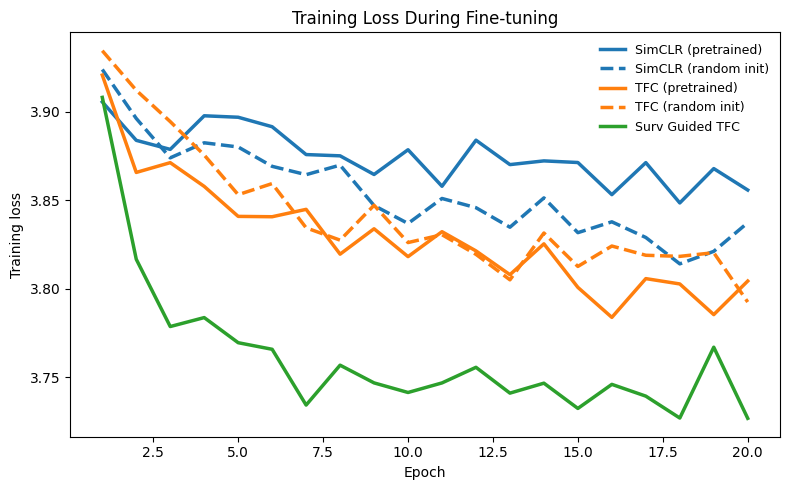

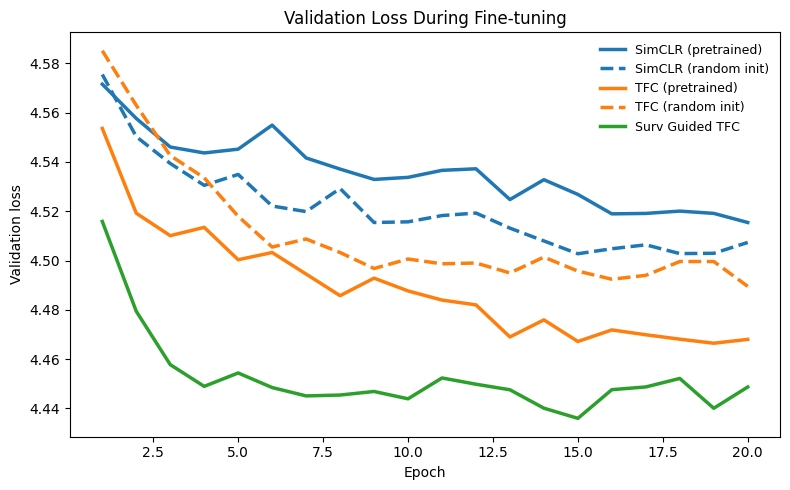

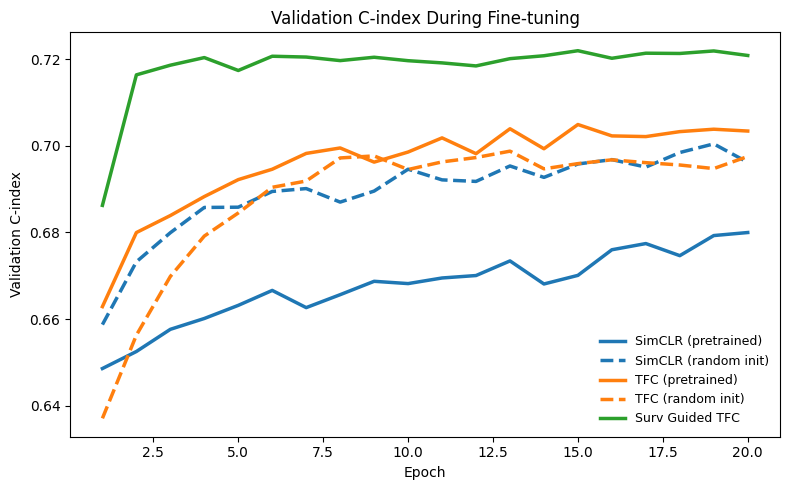

In [41]:
results_dict = {
    "SimCLR (pretrained)": simclr_ssl_results,
    "SimCLR (random init)": random_simclr_results,
    "TFC (pretrained)": tfc_ssl_results,
    "TFC (random init)": random_tfc_results,
    "Surv Guided TFC": surv_guided_tfc_results

}

plot_survival_finetuning_results(results_dict)